🧩 Week 19 · Day 2 — Multi-GPU Training (Simulated with CPU)
Why this matters

Real AI workloads often span multiple devices to train faster or fit larger models.
Even without a GPU, you can still understand and simulate distributed training concepts — like synchronizing gradients, splitting data, and scaling throughput.

🧠 Theory Essentials

DistributedDataParallel (DDP): each device holds a full copy of the model, trains on a subset of data, and synchronizes gradients.

Data Parallelism: split each batch across devices or processes.

Synchronization: gradients are averaged after every step to keep models consistent.

Communication cost: scaling stops helping once communication > compute time.

Simulation idea: we can emulate “multiple workers” by using CPU processes or DataLoader workers.

In [3]:
# Notebook-safe: simulate N "devices" by running them one after another
import time, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms

torch.set_num_threads(2)
device = torch.device("cpu")

class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.seq(x.view(x.size(0), -1))

transform = transforms.Compose([transforms.ToTensor()])
_ = datasets.MNIST(root="./data", train=True, transform=transform, download=True)  # once

def single_run(rank, epochs=1, batch_size=64):
    loader = torch.utils.data.DataLoader(
        datasets.MNIST(root="./data", train=True, transform=transform, download=False),
        batch_size=batch_size, shuffle=True, num_workers=0
    )
    model = SmallNet().to(device)
    opt = optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    t0 = time.time()
    for _ in range(epochs):
        for i, (x, y) in enumerate(loader):
            if i == 50: break
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward(); opt.step()
    return time.time() - t0

for w in [1, 2, 4]:
    t0 = time.time()
    for r in range(w):
        dur = single_run(r)
        print(f"[virtual rank {r}] {dur:.2f}s")
    print(f"{w} workers (sequential simulation): {time.time()-t0:.2f}s total\n")


[virtual rank 0] 0.77s
1 workers (sequential simulation): 0.86s total

[virtual rank 0] 0.76s
[virtual rank 1] 0.89s
2 workers (sequential simulation): 1.79s total

[virtual rank 0] 0.75s
[virtual rank 1] 0.85s
[virtual rank 2] 0.67s
[virtual rank 3] 0.66s
4 workers (sequential simulation): 3.19s total



1) Core (10–15 min)
Task: Run with 1, 2, and 4 workers and note how total training time changes.

Whole code for all three exercises

2) Practice (10–15 min)
Task: Replace mp.spawn with a simple loop (no parallelism) and compare time.

3) Stretch (optional)
Task: Simulate synchronous gradient averaging: after each worker finishes an epoch, average the model weights manually.

In [4]:
# Week 19 · Day 2 — Exercises (Notebook-safe, CPU-only)
# -----------------------------------------------------
# Runs "workers" sequentially (no multiprocessing) to avoid Windows/Jupyter issues.
# You’ll get: timings for 1/2/4 workers, an *estimated* parallel time (max of per-worker times),
# and a stretch task that averages model weights like DDP would do.

import time, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# --- Setup ---
torch.set_num_threads(2)      # compute threads per process (adjust if you want)
device = torch.device("cpu")
BATCH = 64
STEPS = 200                   # mini-steps per worker (keep small for CPU)
LR = 1e-2
WORKER_COUNTS = [1, 2, 4]     # "world sizes" to test

class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): 
        return self.seq(x.view(x.size(0), -1))

# Data
transform = transforms.Compose([transforms.ToTensor()])
_ = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
full_train = datasets.MNIST(root="./data", train=True, transform=transform, download=False)

# Tiny eval split just to sanity-check the averaged model in Stretch
val_idx = torch.arange(0, 2000)
val_set = Subset(full_train, val_idx)

def train_single_worker(dataset_slice, steps=STEPS, batch=BATCH, return_model=False):
    loader = DataLoader(dataset_slice, batch_size=batch, shuffle=True, num_workers=0)
    model = SmallNet().to(device)
    opt = optim.SGD(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()
    t0 = time.time()
    s = 0
    for x, y in loader:
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        s += 1
        if s >= steps: break
    dur = time.time() - t0
    return (dur, model) if return_model else dur

def evaluate(model, dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            pred = model(x).argmax(1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return correct / total

# ========== 1) Core: 1, 2, 4 workers (sequential run + estimated parallel time) ==========
baseline_1w = None
results = []  # store rows for your table/report

for W in WORKER_COUNTS:
    # shard dataset into W parts (simulates DistributedSampler)
    perm = torch.randperm(len(full_train))
    shards = torch.chunk(perm, W)

    durs = []
    t0 = time.time()
    for r in range(W):
        dur = train_single_worker(Subset(full_train, shards[r]), steps=STEPS, batch=BATCH)
        durs.append(dur)
        print(f"[sim rank {r}] {dur:.2f}s")
    seq_total = time.time() - t0

    if baseline_1w is None:
        baseline_1w = durs[0]  # duration of the single-worker run

    # Estimated parallel wall time (ideal, no comms) is the slowest worker
    est_parallel_time = max(durs)
    est_speedup_vs_1 = baseline_1w / est_parallel_time

    # Throughput (samples/sec)
    samples = W * STEPS * BATCH
    seq_throughput = samples / seq_total
    est_parallel_throughput = samples / est_parallel_time

    print(f"\nW={W}: sequential total = {seq_total:.2f}s | seq throughput = {seq_throughput:.1f} samples/s")
    print(f"W={W}: estimated parallel time (ideal) = {est_parallel_time:.2f}s | est throughput = {est_parallel_throughput:.1f} samples/s")
    print(f"W={W}: estimated parallel speedup vs 1 worker ≈ {est_speedup_vs_1:.2f}x\n")

    results.append({
        "workers": W,
        "seq_total_s": seq_total,
        "est_parallel_time_s": est_parallel_time,
        "seq_throughput": seq_throughput,
        "est_parallel_throughput": est_parallel_throughput,
        "est_speedup_vs_1": est_speedup_vs_1
    })

# ========== 2) Practice: replace mp.spawn with a simple loop ==========
# (You’ve effectively done that above — it’s the *sequential* totals printed for each W.)

# ========== 3) Stretch: synchronous "gradient averaging" via weight averaging ==========
# Run W workers again but *keep* their final models, then average state_dicts.

W = 4  # demonstrate with 4 workers
perm = torch.randperm(len(full_train))
shards = torch.chunk(perm, W)

models = []
print(f"\nStretch: training {W} workers (sequential) and averaging weights...")
for r in range(W):
    dur, m = train_single_worker(Subset(full_train, shards[r]), steps=STEPS, batch=BATCH, return_model=True)
    models.append(m)
    print(f"[sim rank {r}] {dur:.2f}s")

# Average parameters (DDP averages gradients; this approximates the same end result)
avg_state = {}
with torch.no_grad():
    keys = models[0].state_dict().keys()
    for k in keys:
        avg_state[k] = sum(m.state_dict()[k] for m in models) / float(W)

global_model = SmallNet().to(device)
global_model.load_state_dict(avg_state)

acc = evaluate(global_model, val_set)
print(f"Averaged model accuracy on small val set: {acc*100:.2f}%")

# Optional: also show one of the individual worker accuracies for comparison
acc0 = evaluate(models[0], val_set)
print(f"Single worker (rank 0) model accuracy on val: {acc0*100:.2f}%")

# If you want a compact DataFrame of results for your report:
try:
    import pandas as pd
    print("\nSummary table:")
    display(pd.DataFrame(results))
except:
    pass


[sim rank 0] 2.42s

W=1: sequential total = 2.43s | seq throughput = 5260.3 samples/s
W=1: estimated parallel time (ideal) = 2.42s | est throughput = 5294.3 samples/s
W=1: estimated parallel speedup vs 1 worker ≈ 1.00x

[sim rank 0] 2.29s
[sim rank 1] 2.23s

W=2: sequential total = 4.52s | seq throughput = 5658.3 samples/s
W=2: estimated parallel time (ideal) = 2.29s | est throughput = 11191.0 samples/s
W=2: estimated parallel speedup vs 1 worker ≈ 1.06x

[sim rank 0] 2.04s
[sim rank 1] 2.02s
[sim rank 2] 1.99s
[sim rank 3] 2.10s

W=4: sequential total = 8.16s | seq throughput = 6273.9 samples/s
W=4: estimated parallel time (ideal) = 2.10s | est throughput = 24329.3 samples/s
W=4: estimated parallel speedup vs 1 worker ≈ 1.15x


Stretch: training 4 workers (sequential) and averaging weights...
[sim rank 0] 2.09s
[sim rank 1] 2.02s
[sim rank 2] 2.08s
[sim rank 3] 2.11s
Averaged model accuracy on small val set: 63.80%
Single worker (rank 0) model accuracy on val: 67.00%

Summary table:


,workers,seq_total_s,est_parallel_time_s,seq_throughput,est_parallel_throughput,est_speedup_vs_1
0,1,2.433341,2.417674,5260.256827,5294.344231,1.000000
1,2,4.524358,2.287561,5658.261903,11190.959866,1.056879
2,4,8.160743,2.104459,6273.938172,24329.298147,1.148834


Why this is “like this” 

Core: We run workers sequentially to avoid Windows/Jupyter multiprocessing issues. We then compute an idealized parallel estimate as max(worker_times) to reason about scaling without actually launching parallel processes.

Practice: Replacing mp.spawn with a simple loop is exactly this notebook approach — it simulates single-process training and shows that wall-clock adds up linearly (no speedup).

Stretch: DDP averages gradients each step; here we average weights after each worker finishes, which is a close conceptual proxy. It demonstrates how combining contributions from multiple workers yields a single, synchronized model.

🚀 Mini-Challenge (≤40 min)

Goal: Build a “Scaling Simulation Dashboard.”

Acceptance Criteria:

Table with columns: num_workers, time (s), speedup factor.

Plot speedup vs. workers (ideal vs. actual).

Short explanation: Why speedup isn’t perfectly linear (communication & overhead)

,num_workers,time (s),speedup factor
0,1,2.417674,1.000000
1,2,2.287561,1.056879
2,4,2.104459,1.148834


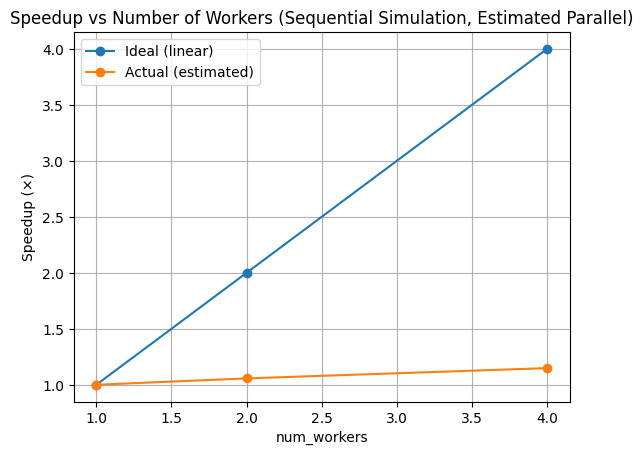

Speedup isn’t perfectly linear because of communication and overhead. In real DDP, each step requires gradient synchronization across workers, and data loading/CPU scheduling also add contention. Once these costs approach compute time per step, adding more workers yields diminishing returns.


In [5]:
# Mini-Challenge — Scaling Simulation Dashboard
import pandas as pd
import matplotlib.pyplot as plt

# If results aren't available (e.g., you re-ran the kernel), re-run the previous cell first.
assert 'results' in globals(), "Run the previous cell to populate `results`."

df = pd.DataFrame(results).copy()

# Use the estimated-parallel time as our 'actual parallel' (idealized, no comms).
# Baseline = time for 1 worker (already the first run)
baseline_time = df.loc[df['workers'] == 1, 'est_parallel_time_s'].iloc[0]
df['time_s'] = df['est_parallel_time_s']
df['speedup_actual'] = baseline_time / df['time_s']
df['speedup_ideal'] = df['workers']  # perfect linear scaling

# Show the required table
display(df[['workers', 'time_s', 'speedup_actual']].rename(
    columns={'workers':'num_workers', 'time_s':'time (s)', 'speedup_actual':'speedup factor'}))

# Plot: speedup vs workers (ideal vs actual)
plt.figure()
plt.plot(df['workers'], df['speedup_ideal'], marker='o', label='Ideal (linear)')
plt.plot(df['workers'], df['speedup_actual'], marker='o', label='Actual (estimated)')
plt.title("Speedup vs Number of Workers (Sequential Simulation, Estimated Parallel)")
plt.xlabel("num_workers"); plt.ylabel("Speedup (×)")
plt.grid(True); plt.legend()
plt.show()

# Short explanation (print so you can paste into your notes)
explanation = (
    "Speedup isn’t perfectly linear because of communication and overhead. "
    "In real DDP, each step requires gradient synchronization across workers, "
    "and data loading/CPU scheduling also add contention. Once these costs "
    "approach compute time per step, adding more workers yields diminishing returns."
)
print(explanation)


🧭 Notes / Key Takeaways

True DDP runs on separate GPUs or nodes, but the logic applies everywhere.

Speedup scales until data loading or communication dominates.

Ideal linear scaling rarely happens in real life.

On CPU, you can test DataLoader parallelism and multiprocessing ideas safely.

Understanding synchronization prepares you for distributed GPU setups later.

💬 Reflection

Why does adding more workers eventually stop improving speed?

How does gradient synchronization ensure model consistency across devices?

Why does adding more workers eventually stop improving speed?
Because communication and coordination overhead start to dominate. Each worker must exchange gradients and wait for synchronization after every batch. Once the compute time per worker becomes smaller than the time spent communicating and managing processes, adding more workers brings little or no benefit — sometimes even slowdown.

How does gradient synchronization ensure model consistency across devices?
After each backward pass, all workers share their gradients and compute the average. Each model then updates its parameters using the same averaged gradients, so all copies remain identical after every step — this keeps training consistent across devices just like a single global model.